In [130]:
# ====================== Часть 1: Подготовка данных ======================
# Проект: Обнаружение аномалий в логах веб-сервера (HDFS)
# Архитектура: LSTM Autoencoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle
import os
from urllib.request import urlretrieve

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [131]:
# 1. Скачиваем датасет
url = "https://raw.githubusercontent.com/logpai/loghub/master/HDFS/HDFS_2k.log"
filename = "HDFS_2k.log"

if not os.path.exists(filename):
    print("Скачиваем HDFS_2k.log...")
    urlretrieve(url, filename)
    print("✅ Датасет скачан!")
else:
    print("✅ Датасет уже есть")

# Загружаем логи
with open(filename, 'r', encoding='utf-8') as f:
    logs = f.readlines()

logs = [line.strip() for line in logs if line.strip()]
print(f"✅ Загружено строк: {len(logs)}")

✅ Датасет уже есть
✅ Загружено строк: 2000


=== Первые 5 логов ===
1: 081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
2: 081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
3: 081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
4: 081109 204015 308 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_8229193803249955061 terminating
5: 081109 204106 329 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-6670958622368987959 terminating

=== Последние 3 лога ===
1998: 081111 101804 26494 INFO dfs.DataNode$DataXceiver: Receiving block blk_-295306975763175640 src: /10.250.9.207:53270 dest: /10.250.9.207:50010
1999: 081111 101954 26414 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_5225719677049010638 terminating
2000: 081111 102017 26347 INFO df

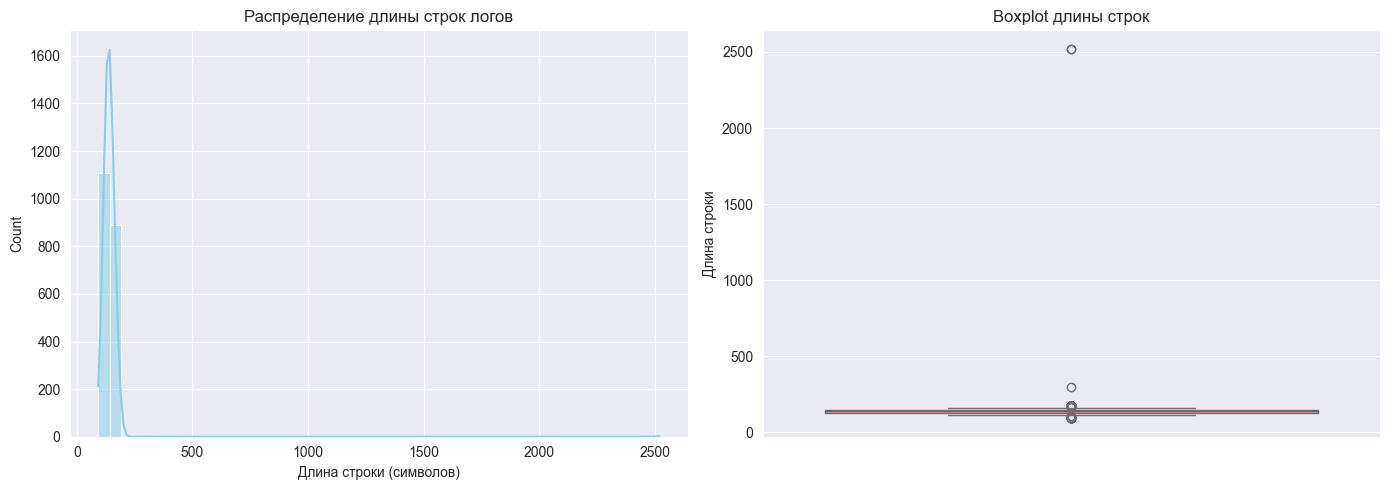

Средняя длина строки: 141.9
Максимальная длина: 2520
Минимальная длина: 93


In [132]:
# 2. EDA — Exploratory Data Analysis

# Примеры логов
print("=== Первые 5 логов ===")
for i in range(5):
    print(f"{i+1}: {logs[i]}")

print("\n=== Последние 3 лога ===")
for i in range(-3, 0):
    print(f"{len(logs)+i+1}: {logs[i]}")

# Длина строк
lengths = [len(line) for line in logs]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(lengths, bins=50, kde=True, color='skyblue')
plt.title('Распределение длины строк логов')
plt.xlabel('Длина строки (символов)')

plt.subplot(1, 2, 2)
sns.boxplot(y=lengths, color='lightcoral')
plt.title('Boxplot длины строк')
plt.ylabel('Длина строки')
plt.tight_layout()
plt.show()

print(f"Средняя длина строки: {np.mean(lengths):.1f}")
print(f"Максимальная длина: {max(lengths)}")
print(f"Минимальная длина: {min(lengths)}")

In [133]:
# 3. Нормализация + токенизация

import re

raw_logs = logs.copy()


def normalize_log(line: str) -> str:
    """Нормализация HDFS-логов до построения словаря."""
    line = line.strip()
    line = re.sub(r'/?\b\d{1,3}(?:\.\d{1,3}){3}(?::\d{1,5})?\b', '[IP]', line)
    line = re.sub(r'blk_-?\d+', '[B]', line)
    line = re.sub(r'\bsize\s+\d+\b', 'size [S]', line)
    line = re.sub(r'(?<!\d)\d{7,}(?!\d)', '[NUM]', line)
    return line


normalized_logs = [normalize_log(line) for line in raw_logs if line.strip()]

print("✅ Нормализация выполнена до создания словаря")
print("Пример до:", raw_logs[0])
print("Пример после:", normalized_logs[0])

# Блок-токены перегружают модель и вызывают коллапс в [b], поэтому исключаем их из обучения.
def is_train_token(token: str) -> bool:
    return '[b]' not in token

# Простая токенизация: lower + split + фильтрация block-токенов
tokens = []
removed_tokens = 0
for line in normalized_logs:
    line = line.lower()
    for token in line.split():
        if is_train_token(token):
            tokens.append(token)
        else:
            removed_tokens += 1

# Создаём словарь (vocab)
vocab = sorted(list(set(tokens)))
word_to_id = {word: idx for idx, word in enumerate(vocab)}
id_to_word = {idx: word for word, idx in word_to_id.items()}

vocab_size = len(vocab)
print(f"✅ Создан словарь!")
print(f"Размер vocabulary: {vocab_size} уникальных токенов")
print(f"Удалено block-токенов: {removed_tokens}")
print(f"Пример токенов: {list(vocab)[:15]} ...")

# Преобразуем все нормализованные логи в одну большую последовательность чисел
sequence = []
for line in normalized_logs:
    line = line.lower()
    for token in line.split():
        if is_train_token(token):
            sequence.append(word_to_id[token])

print(f"Общая длина последовательности: {len(sequence):,} токенов")

✅ Нормализация выполнена до создания словаря
Пример до: 081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
Пример после: 081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block [B] terminating
✅ Создан словарь!
Размер vocabulary: 3102 уникальных токенов
Удалено block-токенов: 2469
Пример токенов: ['/user/root/rand/_temporary/_task_[num]_0001_m_000056_0/part-00056.', '/user/root/rand/_temporary/_task_[num]_0001_m_000097_0/part-00097.', '/user/root/rand/_temporary/_task_[num]_0001_m_000121_0/part-00121.', '/user/root/rand/_temporary/_task_[num]_0001_m_000206_0/part-00206.', '/user/root/rand/_temporary/_task_[num]_0001_m_000346_0/part-00346.', '/user/root/rand/_temporary/_task_[num]_0001_m_000487_0/part-00487.', '/user/root/rand/_temporary/_task_[num]_0001_m_000590_0/part-00590.', '/user/root/rand/_temporary/_task_[num]_0001_m_000742_0/part-00742.', '/user/root/rand/_temporary/_task_[num]_0001_m_00074

In [134]:
# 4. Создаём скользящие окна (sequences)

SEQ_LENGTH = 50          # ← можно менять
step = 5                 # шаг, чтобы не было слишком много пересекающихся окон

sequences = []
for i in range(0, len(sequence) - SEQ_LENGTH, step):
    seq = sequence[i : i + SEQ_LENGTH]
    sequences.append(seq)

X = np.array(sequences)  # shape: (num_sequences, SEQ_LENGTH)

print(f"✅ Создано последовательностей: {X.shape[0]}")
print(f"Форма X: {X.shape}")
print(f"Пример первой последовательности (числа): {X[0][:15]}...")

✅ Создано последовательностей: 4474
Форма X: (4474, 50)
Пример первой последовательности (числа): [ 900 2041 1707 3077 3069 3084 1121 3075 3060 3094  900 2042 2409 3077
 3069]...


In [135]:
# 5. Разделяем на train / test (80/20)

split_idx = int(len(X) * 0.8)
X_train = X[:split_idx]
X_test = X[split_idx:]

print(f"Train: {X_train.shape[0]} последовательностей")
print(f"Test:  {X_test.shape[0]} последовательностей")

Train: 3579 последовательностей
Test:  895 последовательностей


In [136]:
# 6. Сохраняем всё для следующих занятий

data = {
    'X_train': X_train,
    'X_test': X_test,
    'vocab': vocab,
    'word_to_id': word_to_id,
    'id_to_word': id_to_word,
    'seq_length': SEQ_LENGTH,
    'vocab_size': vocab_size,
    'logs': normalized_logs,      # логи, на которых строился словарь и последовательности
    'raw_logs': raw_logs          # сырые логи для демонстрации "до/после"
}

with open('hdfs_preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("✅ Всё сохранено в файл: hdfs_preprocessed_data.pkl")


✅ Всё сохранено в файл: hdfs_preprocessed_data.pkl


In [137]:
# ====================== ЗАНЯТИЕ 2: LSTM Autoencoder ======================
# Проект: Обнаружение аномалий в логах веб-сервера (HDFS)
# Архитектура: LSTM Autoencoder

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Библиотеки загружены")
print("TensorFlow version:", tf.__version__)

✅ Библиотеки загружены
TensorFlow version: 2.20.0


## Интеграция с ClearML

Эксперимент уходит в [ClearML](https://app.clear.ml): метрики обучения, оценка на синтетике, графики и артефакты (`encoder`, словарь, порог).

**Colab:** один раз `!clearml-init` или секреты `CLEARML_API_ACCESS_KEY` / `CLEARML_API_SECRET_KEY` (🔑 в боковой панели).

**Локально:** `pip install clearml` и `clearml-init` в терминале.

Если credentials нет — ноутбук работает без ClearML (`CLEARML_ENABLED = False`).

In [138]:
!clearml-init

/Users/vladimir/edu/mes/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
ClearML SDK setup process
Configuration file already exists: /Users/vladimir/clearml.conf
Leaving setup, feel free to edit the configuration file.


In [ ]:
# ====================== ClearML: установка и инициализация ======================

import os
import sys

# Colab: раскомментируйте при первом запуске
# !pip install -q clearml

# Подхват ключей из Secrets Colab (опционально)
try:
    from google.colab import userdata
    for _env_key in ('CLEARML_API_ACCESS_KEY', 'CLEARML_API_SECRET_KEY'):
        try:
            os.environ[_env_key] = userdata.get(_env_key)
        except userdata.SecretNotFoundError:
            pass
except ImportError:
    pass

CLEARML_ENABLED = False
task = None
logger = None


def cml_log_scalar(title, series, value, iteration=0):
    if CLEARML_ENABLED and logger is not None:
        logger.report_scalar(title, series, float(value), iteration=int(iteration))


def cml_log_single(name, value):
    if CLEARML_ENABLED and logger is not None:
        logger.report_single_value(name, float(value))


def cml_log_figure(title, series, fig=None, iteration=0):
    """Загрузка matplotlib-фигуры в ClearML (API 2.x: report_matplotlib_figure)."""
    if not (CLEARML_ENABLED and logger is not None):
        return
    import matplotlib.pyplot as plt
    figure = fig if fig is not None else plt.gcf()
    iteration = int(iteration)
    if hasattr(logger, 'report_matplotlib_figure'):
        logger.report_matplotlib_figure(
            title=title, series=series, figure=figure, iteration=iteration,
        )
    elif hasattr(logger, 'report_matplotlib_figures'):
        logger.report_matplotlib_figures(
            title=title, series=series, figure=figure, iteration=iteration,
        )
    else:
        print('⚠️ ClearML: нет API для matplotlib, график не загружен')


try:
    from clearml import Task

    task = Task.init(
        project_name='mes/hdfs-anomaly',
        task_name='hdfs-encoder-isolation-forest',
        task_type=Task.TaskTypes.training,
        reuse_last_task_id=False,
        auto_connect_frameworks={'tensorflow': True, 'matplotlib': False},
    )
    logger = task.get_logger()
    CLEARML_ENABLED = True
    print('✅ ClearML: эксперимент создан →', task.get_output_log_web_page())
except Exception as exc:
    print('⚠️ ClearML отключён:', exc)
    print('   Локально/Colab: pip install clearml && clearml-init')

Could not read Jupyter Notebook: No module named 'nbconvert'
Please install nbconvert using "pip install nbconvert"


ClearML Task: created new task id=79bc628903a3423a83d13013e2c4b9ab


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/b12f17b53a0a4af4a300f76a6658f016/experiments/79bc628903a3423a83d13013e2c4b9ab/output/log
✅ ClearML: эксперимент создан → https://app.clear.ml/projects/b12f17b53a0a4af4a300f76a6658f016/experiments/79bc628903a3423a83d13013e2c4b9ab/output/log


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


In [140]:
# ====================== ЗАНЯТИЕ 2: Encoder + Classifier (финальная версия) ======================
# 1) Variable-length последовательности -> подготовка для encoder

import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, GlobalMaxPooling1D, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import IsolationForest

line_sequences = []
line_texts = []
for line in logs:
    ids = [word_to_id[t.lower()] + 1 for t in line.split() if t.lower() in word_to_id]  # +1: 0 reserved for PAD
    if len(ids) >= 5:
        line_sequences.append(ids)
        line_texts.append(line)

lengths = np.array([len(s) for s in line_sequences])
max_len = int(np.percentile(lengths, 95))
max_len = max(20, min(max_len, 120))

X_lines = pad_sequences(line_sequences, maxlen=max_len, padding='post', truncating='post', value=0)

split_idx = int(len(X_lines) * 0.8)
X_train_lines = X_lines[:split_idx]
X_test_lines = X_lines[split_idx:]
test_logs = line_texts[split_idx:]

print(f"✅ Подготовлено строк: {len(line_sequences)}")
print(f"Длина последовательности (p95): {max_len}")
print(f"Train/Test: {X_train_lines.shape} / {X_test_lines.shape}")

if CLEARML_ENABLED:
    task.connect({
        'vocab_size': int(vocab_size),
        'max_len': int(max_len),
        'n_lines': int(len(line_sequences)),
        'n_train_lines': int(len(X_train_lines)),
        'n_test_lines': int(len(X_test_lines)),
        'embed_dim': 64,
        'iso_n_estimators': 300,
        'iso_contamination': 0.05,
    })


✅ Подготовлено строк: 2000
Длина последовательности (p95): 20
Train/Test: (1600, 20) / (400, 20)


In [141]:
# 2) Self-supervised encoder pretraining
# Обучаем seq2seq, но для аномалий используем только encoder -> fixed vector z

vocab_size_with_pad = vocab_size + 1  # token 0 is PAD

inp = Input(shape=(None,), name='tokens')
x = Embedding(input_dim=vocab_size_with_pad, output_dim=64, mask_zero=True, name='embed')(inp)
x = Bidirectional(LSTM(64, return_sequences=True), name='bilstm_enc')(x)
z = GlobalMaxPooling1D(name='z_pool')(x)
z = Dense(128, activation='relu', name='z_dense')(z)

# Decoder only for self-supervised objective
h = RepeatVector(max_len, name='repeat')(z)
h = LSTM(64, return_sequences=True, name='lstm_dec')(h)
out = TimeDistributed(Dense(vocab_size_with_pad, activation='softmax'), name='token_probs')(h)

seq2seq = Model(inp, out, name='seq_encoder_pretrain')
seq2seq.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

counts = np.bincount(X_train_lines.reshape(-1), minlength=vocab_size_with_pad).astype(np.float32)
base_w = 1.0 / np.sqrt(counts + 1.0)
base_w = base_w / np.mean(base_w[1:])
base_w = np.clip(base_w, 0.2, 6.0)
base_w[0] = 0.0
if 'info' in word_to_id:
    base_w[word_to_id['info'] + 1] *= 0.4

train_w = base_w[X_train_lines]
val_w = base_w[X_test_lines]

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

# ClearML 2.x: модуля clearml.integration.keras нет — loss/val_loss пишем вручную после fit
fit_callbacks = [early_stop, reduce_lr]

print('🚀 Pretraining encoder (self-supervised)...')
history_enc = seq2seq.fit(
    X_train_lines, X_train_lines,
    sample_weight=train_w,
    validation_data=(X_test_lines, X_test_lines, val_w),
    epochs=20,
    batch_size=128,
    callbacks=fit_callbacks,
    verbose=1
)

if CLEARML_ENABLED:
    for epoch, (loss, val_loss) in enumerate(zip(
        history_enc.history['loss'], history_enc.history['val_loss']
    )):
        cml_log_scalar('encoder', 'loss', loss, epoch)
        cml_log_scalar('encoder', 'val_loss', val_loss, epoch)
    cml_log_single('encoder_best_val_loss', min(history_enc.history['val_loss']))

encoder = Model(inp, z, name='hdfs_encoder')
encoder.save('hdfs_encoder.keras')
print('✅ Encoder saved: hdfs_encoder.keras')


🚀 Pretraining encoder (self-supervised)...
Epoch 1/20


/Users/vladimir/edu/mes/.venv/lib/python3.9/site-packages/keras/src/layers/layer.py:965: UserWarning:

Layer 'z_pool' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.

/Users/vladimir/edu/mes/.venv/lib/python3.9/site-packages/keras/src/layers/layer.py:965: UserWarning:

Layer 'z_pool' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.



13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.1983

/Users/vladimir/edu/mes/.venv/lib/python3.9/site-packages/keras/src/layers/layer.py:965: UserWarning:

Layer 'z_pool' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.



13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 1.1984 - val_loss: 1.4346 - learning_rate: 0.0010
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.1713 - val_loss: 1.3486 - learning_rate: 0.0010
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.0456 - val_loss: 1.3267 - learning_rate: 0.0010
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.9600 - val_loss: 1.3648 - learning_rate: 0.0010
Epoch 5/20
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9385
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.9390 - val_loss: 1.3993 - learning_rate: 0.0010
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.9335 - val_loss: 1.4077 - learning_rate: 5.0000e-04
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.9312
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.9314 - val_loss: 1.4179 - lear

In [142]:
# 3) Unsupervised classifier on embeddings (IsolationForest)

Z_train = encoder.predict(X_train_lines, batch_size=256, verbose=0)
Z_test = encoder.predict(X_test_lines, batch_size=256, verbose=0)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(Z_train)

train_scores = -iso.decision_function(Z_train)
test_scores = -iso.decision_function(Z_test)
threshold = np.percentile(train_scores, 95)

train_anomaly = train_scores > threshold
test_anomaly = test_scores > threshold

print('✅ IsolationForest trained')
print(f'Threshold (95th percentile): {threshold:.4f}')
print(f'Train anomaly rate: {train_anomaly.mean() * 100:.2f}%')
print(f'Test anomaly rate: {test_anomaly.mean() * 100:.2f}%')

if CLEARML_ENABLED:
    cml_log_single('threshold', threshold)
    cml_log_single('hdfs_train_anomaly_rate_pct', train_anomaly.mean() * 100)
    cml_log_single('hdfs_test_anomaly_rate_pct', test_anomaly.mean() * 100)
    cml_log_single('hdfs_train_score_mean', train_scores.mean())
    cml_log_single('hdfs_test_score_mean', test_scores.mean())


/Users/vladimir/edu/mes/.venv/lib/python3.9/site-packages/keras/src/layers/layer.py:965: UserWarning:

Layer 'z_pool' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.



✅ IsolationForest trained
Threshold (95th percentile): -0.0000
Train anomaly rate: 5.00%
Test anomaly rate: 8.50%


In [143]:
# 4) Детекция на новой строке + quick demo

def detect_anomaly_line(log_line: str):
    norm = normalize_log(log_line)
    ids = [word_to_id[t.lower()] + 1 for t in norm.split() if t.lower() in word_to_id]

    if len(ids) == 0:
        return {
            'is_anomaly': True,
            'score': float('inf'),
            'threshold': float(threshold),
            'reason': 'no known tokens after preprocessing'
        }

    x = pad_sequences([ids], maxlen=max_len, padding='post', truncating='post', value=0)
    z_vec = encoder.predict(x, verbose=0)
    score = float(-iso.decision_function(z_vec)[0])

    return {
        'is_anomaly': bool(score > threshold),
        'score': score,
        'threshold': float(threshold),
        'reason': 'ok'
    }

examples = [
    logs[0],
    logs[min(100, len(logs)-1)],
    '081111 235959 9999 WARN dfs.unknown: panic timeout from 10.10.10.10 blk_999999999999999999 size 999999999'
]

for i, ex in enumerate(examples, 1):
    res = detect_anomaly_line(ex)
    print(f"Example {i}: anomaly={res['is_anomaly']} | score={res['score']:.4f} | thr={res['threshold']:.4f}")
    print(ex[:180], '...')
    print('-' * 80)


Example 1: anomaly=False | score=-0.1331 | thr=-0.0000
081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating ...
--------------------------------------------------------------------------------
Example 2: anomaly=False | score=-0.0137 | thr=-0.0000
081109 224420 3666 WARN dfs.DataNode$DataXceiver: 10.251.73.188:50010:Got exception while serving blk_7517964792804498202 to /10.250.6.191: ...
--------------------------------------------------------------------------------
Example 3: anomaly=True | score=0.1540 | thr=-0.0000
081111 235959 9999 WARN dfs.unknown: panic timeout from 10.10.10.10 blk_999999999999999999 size 999999999 ...
--------------------------------------------------------------------------------


/Users/vladimir/edu/mes/.venv/lib/python3.9/site-packages/clearml/utilities/plotlympl/mplexporter/exporter.py:101: UserWarning:

Blended transforms not yet supported. Zoom behavior may not work as expected.



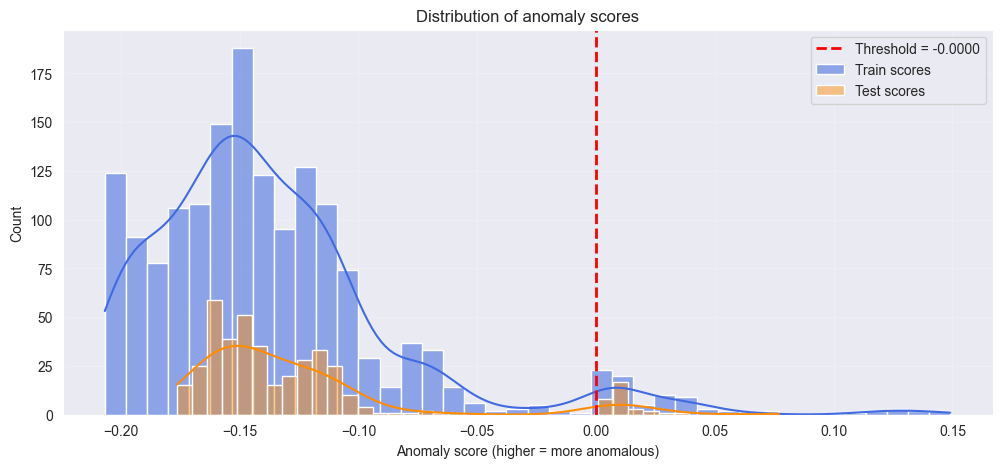

In [144]:
# 5) Графики: распределение anomaly score

import matplotlib.pyplot as plt
import seaborn as sns

fig_scores = plt.figure(figsize=(12, 5))
sns.histplot(train_scores, bins=40, color='royalblue', alpha=0.55, label='Train scores', kde=True)
sns.histplot(test_scores, bins=40, color='darkorange', alpha=0.45, label='Test scores', kde=True)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.title('Distribution of anomaly scores')
plt.xlabel('Anomaly score (higher = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.2)
cml_log_figure('hdfs_eval', 'score_distribution', fig=fig_scores)
plt.show()


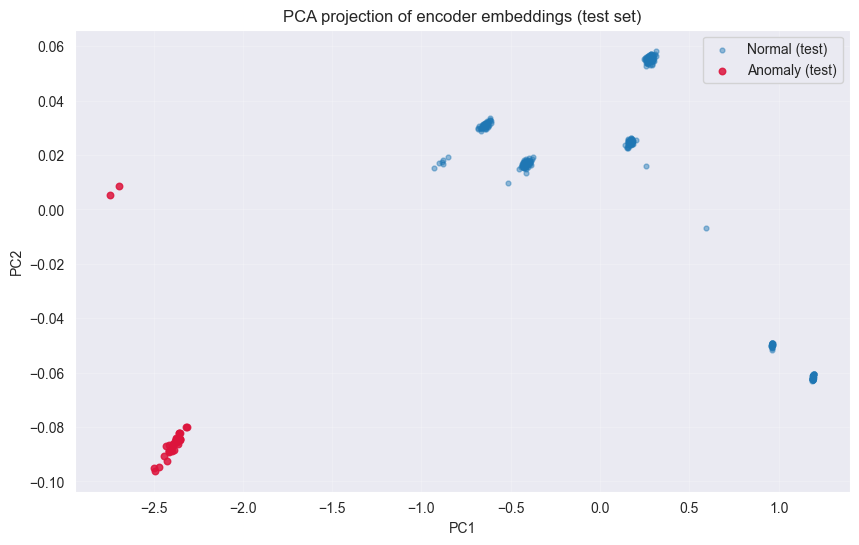

Топ подозрительных логов (test):


,score,is_anomaly,log
0,0.076973,True,081111 093742 13 INFO dfs.DataBlockScanner: Ve...
1,0.071409,True,081111 070232 13 INFO dfs.DataBlockScanner: Ve...
2,0.036130,True,081111 075158 33 INFO dfs.FSNamesystem: BLOCK*...
3,0.031869,True,081111 085059 31 INFO dfs.FSNamesystem: BLOCK*...
4,0.024852,True,081111 084728 31 INFO dfs.FSNamesystem: BLOCK*...
5,0.020364,True,081111 094713 29 INFO dfs.FSNamesystem: BLOCK*...
6,0.014978,True,081111 094825 35 INFO dfs.FSNamesystem: BLOCK*...
7,0.014067,True,081111 082527 31 INFO dfs.FSNamesystem: BLOCK*...
8,0.014063,True,081111 085634 30 INFO dfs.FSNamesystem: BLOCK*...
9,0.012659,True,081111 092311 35 INFO dfs.FSNamesystem: BLOCK*...


In [145]:
# 6) График эмбеддингов (2D) + таблица топ аномалий

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Z_test)

fig_pca = plt.figure(figsize=(10, 6))
plt.scatter(Z2[~test_anomaly, 0], Z2[~test_anomaly, 1], s=12, alpha=0.45, label='Normal (test)')
plt.scatter(Z2[test_anomaly, 0], Z2[test_anomaly, 1], s=22, alpha=0.85, c='crimson', label='Anomaly (test)')
plt.title('PCA projection of encoder embeddings (test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.2)
cml_log_figure('hdfs_eval', 'pca_embeddings', fig=fig_pca)
plt.show()

top_k = min(10, len(test_scores))
top_idx = np.argsort(test_scores)[-top_k:][::-1]
top_df = pd.DataFrame({
    'score': test_scores[top_idx],
    'is_anomaly': test_anomaly[top_idx],
    'log': [test_logs[i][:180] + ('...' if len(test_logs[i]) > 180 else '') for i in top_idx]
})
print('Топ подозрительных логов (test):')
display(top_df)


## Синтетический датасет с известными метками

Ниже генерируем искусственные логи: часть **нормальная** (похожа на HDFS), часть **аномальная** (другой формат, WARN/ERROR, неизвестные компоненты и т.д.).  
У каждой строки есть ground truth — затем прогоняем обученную модель и смотрим precision / recall / F1.

In [146]:
# ====================== Синтетические логи (ground truth) ======================

import random
from dataclasses import dataclass

random.seed(42)
np.random.seed(42)


@dataclass
class SyntheticSample:
    log: str
    is_anomaly: bool
    anomaly_type: str  # 'normal' или тип аномалии


def _pick_normal_templates(source_logs, k):
    """Берём реальные HDFS-строки как эталон нормы."""
    pool = [ln for ln in source_logs if len(ln.split()) >= 8]
    if len(pool) >= k:
        return random.sample(pool, k)
    return random.choices(pool, k=k)


def _make_anomaly(kind, base=None):
    """Генераторы аномалий разных типов."""
    if kind == 'foreign_format':
        return '192.168.0.1 - - [17/May/2026:12:00:01 +0000] "GET /admin HTTP/1.1" 500 1234'

    if kind == 'warn_panic':
        return '081111 235959 9999 WARN dfs.FSNamesystem: panic timeout while waiting for block blk_-999999999999999999'

    if kind == 'unknown_component':
        return '081111 120000 42 ERROR dfs.UnknownService: corrupted metadata on /10.0.0.1:50010 blk_1234567890123456789'

    if kind == 'garbage':
        return '!!! CRITICAL $$$ heap overflow ??? 0xDEADBEEF @@@'

    if kind == 'too_short':
        return '081111 fail'

    if kind == 'mutated_normal' and base:
        # Похоже на HDFS, но с подозрительными вставками
        parts = base.split()
        parts.insert(4, 'FATAL')
        parts.append('exception=NullPointer')
        return ' '.join(parts)

    return '081111 000000 1 UNKNOWN totally broken log line'


ANOMALY_KINDS = [
    'foreign_format',
    'warn_panic',
    'unknown_component',
    'garbage',
    'too_short',
    'mutated_normal',
]


def generate_synthetic_dataset(
    source_logs,
    n_normal=300,
    n_anomaly=100,
    seed=42,
):
    """
    Возвращает список SyntheticSample с известными метками.
    """
    random.seed(seed)
    np.random.seed(seed)

    samples = []

    for line in _pick_normal_templates(source_logs, n_normal):
        samples.append(SyntheticSample(line, False, 'normal'))

    normals_for_mutation = _pick_normal_templates(source_logs, max(20, n_anomaly // len(ANOMALY_KINDS) + 1))

    for i in range(n_anomaly):
        kind = ANOMALY_KINDS[i % len(ANOMALY_KINDS)]
        base = normals_for_mutation[i % len(normals_for_mutation)] if kind == 'mutated_normal' else None
        samples.append(SyntheticSample(_make_anomaly(kind, base), True, kind))

    random.shuffle(samples)
    return samples


# --- генерация ---
N_NORMAL = 300
N_ANOMALY = 100

synthetic_samples = generate_synthetic_dataset(logs, n_normal=N_NORMAL, n_anomaly=N_ANOMALY)
synthetic_logs = [s.log for s in synthetic_samples]
y_true = np.array([s.is_anomaly for s in synthetic_samples], dtype=bool)
anomaly_types = [s.anomaly_type for s in synthetic_samples]

print(f"✅ Синтетический датасет: {len(synthetic_samples)} строк")
print(f"   Нормальных: {(~y_true).sum()} | Аномалий: {y_true.sum()}")
print(f"   Доля аномалий: {y_true.mean() * 100:.1f}%")

# Распределение типов аномалий
from collections import Counter
type_counts = Counter(anomaly_types)
print("\nТипы в датасете:")
for t, c in sorted(type_counts.items()):
    print(f"  {t:20s} {c:4d}")

print("\n=== Примеры нормальных ===")
for s in [x for x in synthetic_samples if not x.is_anomaly][:2]:
    print(s.log[:140], '...')

print("\n=== Примеры аномалий ===")
for s in [x for x in synthetic_samples if x.is_anomaly][:3]:
    print(f"[{s.anomaly_type}] {s.log[:140]} ...")

if CLEARML_ENABLED:
    task.connect({
        'n_normal_synth': int(N_NORMAL),
        'n_anomaly_synth': int(N_ANOMALY),
        'synth_seed': 42,
    })

✅ Синтетический датасет: 400 строк
   Нормальных: 300 | Аномалий: 100
   Доля аномалий: 25.0%

Типы в датасете:
  foreign_format         17
  garbage                17
  mutated_normal         16
  normal                300
  too_short              16
  unknown_component      17
  warn_panic             17

=== Примеры нормальных ===
081111 031334 30 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.26.8:50010 is added to blk_-5963475042722 ...
081110 133946 11947 WARN dfs.DataNode$DataXceiver: 10.251.126.255:50010:Got exception while serving blk_1910039736720341651 to /10.251.31.85 ...

=== Примеры аномалий ===
[unknown_component] 081111 120000 42 ERROR dfs.UnknownService: corrupted metadata on /10.0.0.1:50010 blk_1234567890123456789 ...
[foreign_format] 192.168.0.1 - - [17/May/2026:12:00:01 +0000] "GET /admin HTTP/1.1" 500 1234 ...
[too_short] 081111 fail ...


ОЦЕНКА НА СИНТЕТИЧЕСКОМ ДАТАСЕТЕ (ground truth известен)
Порог anomaly score: -0.0000
Precision: 0.955
Recall:    0.840
F1:        0.894

Confusion matrix (rows=true, cols=pred):
              pred Normal  pred Anomaly
true Normal         296             4
true Anomaly         16            84

              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       300
     Anomaly       0.95      0.84      0.89       100

    accuracy                           0.95       400
   macro avg       0.95      0.91      0.93       400
weighted avg       0.95      0.95      0.95       400

Строк с score=inf (нет токенов в словаре): 17
ROC-AUC (по score): 0.933
PR-AUC  (по score): 0.900


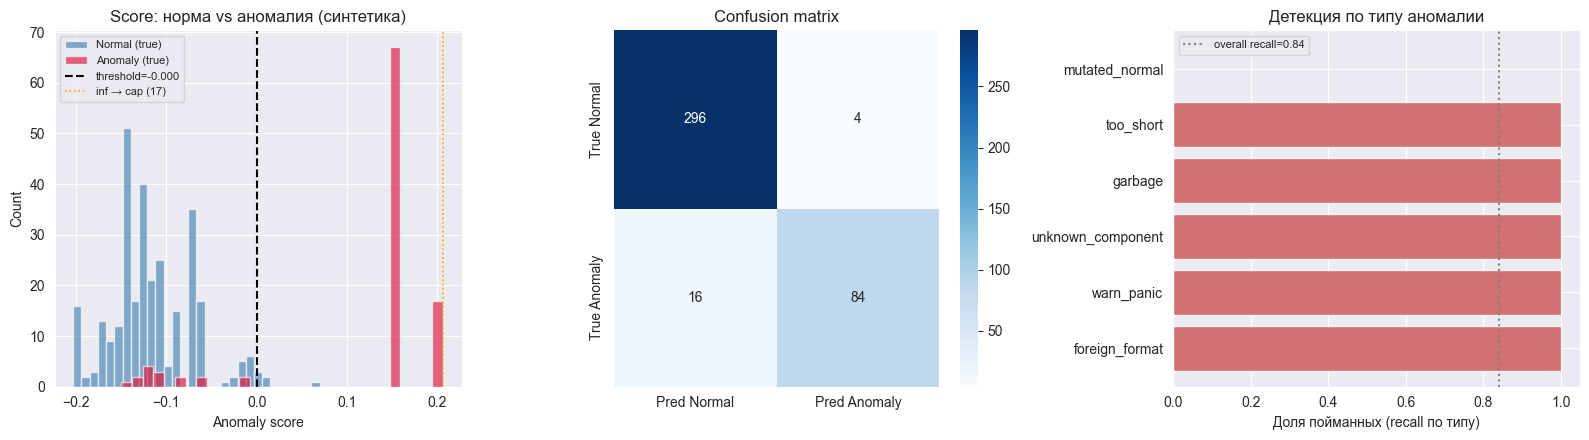


False Positive (норма → аномалия) (4 шт.), примеры:
  [normal] score=0.0697 pred=True | 081111 044337 13 INFO dfs.DataBlockScanner: Verification succeeded for blk_-6160667975382232149...
  [normal] score=0.0105 pred=True | 081110 002337 13 INFO dfs.DataBlockScanner: Verification succeeded for blk_-1547954353065580372...
  [normal] score=0.0052 pred=True | 081110 121943 29 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /user/root/randtxt2/_temporary/_task_2008111010...
  [normal] score=0.0146 pred=True | 081109 234110 26 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /user/root/sortrand/_temporary/_task_2008110920...

False Negative (аномалия → норма) (16 шт.), примеры:
  [mutated_normal] score=-0.0613 pred=False | 081110 011001 26 INFO FATAL dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.25.237:50010 is...
  [mutated_normal] score=-0.1262 pred=False | 081111 043515 20251 INFO FATAL dfs.DataNode$PacketResponder: Received block blk_4443043

In [147]:
# ====================== Оценка модели на синтетике ======================
# Сначала выполните ячейки: обучение encoder + IsolationForest, затем генератор синтетики.

_required = ['synthetic_logs', 'y_true', 'anomaly_types', 'detect_anomaly_line', 'threshold', 'encoder', 'iso', 'max_len', 'word_to_id', 'normalize_log', 'pad_sequences', 'ANOMALY_KINDS']
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise NameError(
        'Не хватает переменных: ' + ', '.join(_missing) +
        '. Запустите ячейки обучения модели и генератора синтетики.'
    )

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
)


def score_logs_batch(log_lines):
    """Пакетный расчёт anomaly score (быстрее, чем detect_anomaly_line в цикле)."""
    batch_ids = []
    empty_mask = []
    for line in log_lines:
        norm = normalize_log(line)
        ids = [word_to_id[t.lower()] + 1 for t in norm.split() if t.lower() in word_to_id]
        empty_mask.append(len(ids) == 0)
        batch_ids.append(ids if ids else [0])

    X = pad_sequences(batch_ids, maxlen=max_len, padding='post', truncating='post', value=0)
    Z = encoder.predict(X, batch_size=64, verbose=0)
    scores = -iso.decision_function(Z).astype(float)
    for i, is_empty in enumerate(empty_mask):
        if is_empty:
            scores[i] = np.inf
    return scores


# Прогоняем детектор
scores = score_logs_batch(synthetic_logs)
y_pred = scores > threshold

# Метрики (порог зафиксирован на train HDFS)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='binary', zero_division=0
)
cm = confusion_matrix(y_true, y_pred, labels=[False, True])
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("ОЦЕНКА НА СИНТЕТИЧЕСКОМ ДАТАСЕТЕ (ground truth известен)")
print("=" * 60)
print(f"Порог anomaly score: {threshold:.4f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
print()
print("Confusion matrix (rows=true, cols=pred):")
print(f"              pred Normal  pred Anomaly")
print(f"true Normal      {tn:6d}        {fp:6d}")
print(f"true Anomaly     {fn:6d}        {tp:6d}")
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0))

# AUC по непрерывному score (если есть вариация)
finite = np.isfinite(scores)
n_inf = int((~finite).sum())
if n_inf:
    print(f"Строк с score=inf (нет токенов в словаре): {n_inf}")

roc_auc_val = pr_auc_val = None
if len(np.unique(scores[finite])) > 1:
    roc_auc_val = roc_auc_score(y_true[finite], scores[finite])
    pr_auc_val = average_precision_score(y_true[finite], scores[finite])
    print(f"ROC-AUC (по score): {roc_auc_val:.3f}")
    print(f"PR-AUC  (по score): {pr_auc_val:.3f}")

# Для графиков — только конечные score (matplotlib не умеет inf в bins)
scores_plot = scores.copy()
if finite.any():
    score_cap = float(np.percentile(scores[finite], 99.5) + 0.05)
    scores_plot[~finite] = score_cap
else:
    score_cap = 1.0

# --- визуализация ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Распределение score
ax = axes[0]
ax.hist(scores_plot[~y_true], bins=30, alpha=0.65, label='Normal (true)', color='steelblue')
ax.hist(scores_plot[y_true], bins=30, alpha=0.65, label='Anomaly (true)', color='crimson')
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5, label=f'threshold={threshold:.3f}')
if n_inf:
    ax.axvline(score_cap, color='orange', linestyle=':', linewidth=1.2, label=f'inf → cap ({n_inf})')
ax.set_xlabel('Anomaly score')
ax.set_ylabel('Count')
ax.set_title('Score: норма vs аномалия (синтетика)')
ax.legend(fontsize=8)

# 2) Confusion matrix heatmap
ax = axes[1]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred Normal', 'Pred Anomaly'],
    yticklabels=['True Normal', 'True Anomaly'],
    ax=ax,
)
ax.set_title('Confusion matrix')

# 3) Recall по типу аномалии
ax = axes[2]
type_recall = {}
for kind in ANOMALY_KINDS:
    mask = np.array([t == kind for t in anomaly_types])
    if mask.sum() == 0:
        continue
    type_recall[kind] = y_pred[mask].mean()

if type_recall:
    kinds = list(type_recall.keys())
    vals = [type_recall[k] for k in kinds]
    bars = ax.barh(kinds, vals, color='indianred', alpha=0.85)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Доля пойманных (recall по типу)')
    ax.set_title('Детекция по типу аномалии')
    ax.axvline(recall, color='gray', linestyle=':', label=f'overall recall={recall:.2f}')
    ax.legend(fontsize=8)
    # подписи на столбцах — чтобы не казалось, что все «1.0»
    for bar, v in zip(bars, vals):
        ax.text(
            min(v + 0.02, 1.02), bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}', va='center', fontsize=9,
        )

print('\n--- Recall по типу аномалии (только строки-аномалии) ---')
for kind in ANOMALY_KINDS:
    mask = np.array([t == kind for t in anomaly_types])
    if mask.sum() == 0:
        continue
    rec_k = y_pred[mask].mean()
    n_caught = int(y_pred[mask].sum())
    print(f'  {kind:20s}  n={mask.sum():2d}  caught={n_caught:2d}  recall={rec_k:.3f}')

plt.tight_layout()
plt.show()

if CLEARML_ENABLED:
    cml_log_single('synth_precision', precision)
    cml_log_single('synth_recall', recall)
    cml_log_single('synth_f1', f1)
    cml_log_single('synth_accuracy', (tp + tn) / len(y_true))
    cml_log_single('synth_fp', fp)
    cml_log_single('synth_fn', fn)
    if roc_auc_val is not None:
        cml_log_single('synth_roc_auc', roc_auc_val)
        cml_log_single('synth_pr_auc', pr_auc_val)
    for kind, rec in type_recall.items():
        cml_log_scalar('synth_recall_by_type', kind, rec)
    # напрямую — не зависит от устаревшей cml_log_figure в памяти kernel
    if hasattr(logger, 'report_matplotlib_figure'):
        logger.report_matplotlib_figure(
            title='synthetic_eval', series='dashboard', figure=fig, iteration=0,
        )
    else:
        cml_log_figure('synthetic_eval', 'dashboard', fig=fig)

# --- таблица ошибок ---
def _show_mistakes(title, mask, n=5):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        print(f"\n{title}: нет")
        return
    print(f"\n{title} ({len(idx)} шт.), примеры:")
    for i in idx[:n]:
        sc = scores[i]
        sc_txt = 'inf' if not np.isfinite(sc) else f'{sc:.4f}'
        print(f"  [{anomaly_types[i]}] score={sc_txt} pred={y_pred[i]} | {synthetic_logs[i][:120]}...")

_show_mistakes('False Positive (норма → аномалия)', (~y_true) & y_pred)
_show_mistakes('False Negative (аномалия → норма)', y_true & (~y_pred))
_show_mistakes('True Positive (аномалия поймана)', y_true & y_pred, n=5)

In [148]:
# ====================== ClearML: артефакты и завершение ======================

if CLEARML_ENABLED:
    import pickle

    run_meta = {
        'threshold': float(threshold),
        'max_len': int(max_len),
        'vocab_size': int(vocab_size),
        'word_to_id': word_to_id,
    }
    with open('run_artifacts.pkl', 'wb') as f:
        pickle.dump(run_meta, f)

    task.upload_artifact('preprocess_and_threshold', artifact_object='run_artifacts.pkl')

    if os.path.exists('hdfs_encoder.keras'):
        task.upload_artifact('hdfs_encoder', artifact_object='hdfs_encoder.keras')

    if os.path.exists('hdfs_preprocessed_data.pkl'):
        task.upload_artifact('hdfs_preprocessed_data', artifact_object='hdfs_preprocessed_data.pkl')

    print('📦 Артефакты загружены в ClearML')
    print('🔗', task.get_output_log_web_page())

    task.close()
    print('✅ ClearML task закрыт')
else:
    print('ClearML не активен — артефакты только локально (hdfs_encoder.keras, run_artifacts.pkl)')

📦 Артефакты загружены в ClearML
🔗 https://app.clear.ml/projects/b12f17b53a0a4af4a300f76a6658f016/experiments/79bc628903a3423a83d13013e2c4b9ab/output/log
✅ ClearML task закрыт
